# Quark/Gluon Jet Classification : GCN vs GAT


**Dataset:** ParticleNet Quark–Gluon (`.npz` files)  
**Features per particle:** `[pt, rapidity, phi, pdgid]`  
**Task:** Binary classification — Quark (1) vs Gluon (0)  
**Graph construction:** k-nearest neighbors (k = 16) in rapidity–phi space  

## Citation


This work uses the ParticleNet quark–gluon dataset.

Komiske, P. T., Metodiev, E. M., & Thaler, J. (2019).  
*Energy Flow Networks: Deep Sets for Particle Jets.*  
Journal of High Energy Physics (JHEP), 01 (2019) 121.  
arXiv: https://arxiv.org/abs/1810.05165

In [ ]:

!pip install torch-geometric -q
import torch
TORCH = torch.__version__.split('+')[0]          
CUDA  = 'cu' + torch.version.cuda.replace('.','') 
WHEEL = f'https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html'
print(f'Wheel URL: {WHEEL}')

!pip install torch-scatter torch-sparse torch-cluster -f {WHEEL} -q

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Wheel URL: https://data.pyg.org/whl/torch-2.9.0+cu126.html


## Dependencies

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings, os
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, knn_graph

from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.model_selection import train_test_split

## Dataset

In [4]:
FILES = [
    '/kaggle/input/datasets/kthirukumaran/quark-gluon-jet/QG_jets_7.npz',
    '/kaggle/input/datasets/kthirukumaran/quark-gluon-jet/QG_jets_10.npz'
]

X_list, y_list = [], []
for f in FILES:
    d = np.load(f)
    X_list.append(d['X'])
    y_list.append(d['y'])
    print(f'Loaded {f.split("/")[-1]} — X: {d["X"].shape}')

max_M = max(x.shape[1] for x in X_list)

X_list = [
    np.pad(x, ((0,0), (0, max_M - x.shape[1]), (0,0)), mode='constant')
    for x in X_list
]

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print(f'Total X : {X.shape}')
print(f'Total y : {y.shape}')
print(f'Gluon (0): {(y==0).sum():,} | Quark (1): {(y==1).sum():,}')

Loaded QG_jets_7.npz — X: (100000, 136, 4)
Loaded QG_jets_10.npz — X: (100000, 138, 4)
Total X : (200000, 138, 4)
Total y : (200000,)
Gluon (0): 100,000 | Quark (1): 100,000


## Graph Construction:

| Component | Choice | Reason |
|-----------|--------|---------|
| **Nodes** | Each non-zero particle | Direct Representation of jets particle structure |
| **Node features** | [log(pt), rapidity, phi, encoded_pdgid] | log(pt) stabilises scale; rapidity+phi define jet geometry and position |
| **Edges** | kNN (k=16) in rapidity-φ space | Particles close in angle inside the jet more likely to interact  |
| **Padding removal** | Mask out pt = 0 particles | Zero-padded entries carry no physical information |
| **pdgid encoding** | Map to compact integer index | Raw pdgid values are large integers ,encoding to small values makes it easier for the model |

In [29]:
# Encoding pdgid

PDGID_MAP = {
    0: 0, 22: 1, 211: 2, -211: 3, 130: 4,
    11: 5, -11: 6, 13: 7, -13: 8,
    321: 9, -321: 10, 2212: 11, -2212: 12, 2112: 13
}
PDGID_DEFAULT = 14

def build_graph(jet, label, k=16):
    # Remove zero padding particles
    mask = jet[:, 0] > 0
    jet  = jet[mask]
    if len(jet) < 2:
        return None

    pt       = jet[:, 0].astype(np.float32)
    rapidity = jet[:, 1].astype(np.float32)
    phi      = jet[:, 2].astype(np.float32)
    pdgid    = np.array(
        [PDGID_MAP.get(int(p), PDGID_DEFAULT) for p in jet[:, 3]],
        dtype=np.float32
    )

    # Node features: [log(pt), rapidity, phi, encoded_pdgid]
    node_feats = np.stack([np.log(pt + 1e-8), rapidity, phi, pdgid], axis=1)
    x          = torch.tensor(node_feats, dtype=torch.float)
    y_label    = torch.tensor([label],    dtype=torch.long)

    # kNN graph in rapidity-phi space
    pos        = torch.tensor(np.stack([rapidity, phi], axis=1), dtype=torch.float)
    edge_index = knn_graph(pos, k=min(k, len(jet) - 1), loop=False)

    return Data(x=x, edge_index=edge_index, y=y_label)


print('Building graphs...')
graph_list = []
for i in range(len(X)):
    g = build_graph(X[i], int(y[i]))
    if g is not None:
        graph_list.append(g)
    if (i + 1) % 10000 == 0:
        print(f'  {i+1:,} / {len(X):,} processed')

Building graphs...
  10,000 / 200,000 processed
  20,000 / 200,000 processed
  30,000 / 200,000 processed
  40,000 / 200,000 processed
  50,000 / 200,000 processed
  60,000 / 200,000 processed
  70,000 / 200,000 processed
  80,000 / 200,000 processed
  90,000 / 200,000 processed
  100,000 / 200,000 processed
  110,000 / 200,000 processed
  120,000 / 200,000 processed
  130,000 / 200,000 processed
  140,000 / 200,000 processed
  150,000 / 200,000 processed
  160,000 / 200,000 processed
  170,000 / 200,000 processed
  180,000 / 200,000 processed
  190,000 / 200,000 processed
  200,000 / 200,000 processed


## Train / Val / Test Split

In [30]:
train_data, test_data = train_test_split(graph_list, test_size=0.15, random_state=42)
train_data, val_data  = train_test_split(train_data, test_size=0.15, random_state=42)

print(f'Train : {len(train_data):,}')
print(f'Val   : {len(val_data):,}')
print(f'Test  : {len(test_data):,}')

BATCH = 256  
train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

Train : 144,500
Val   : 25,500
Test  : 30,000


## Model Definitions

### GCN — Graph Convolutional Network
Aggregates neighbor features with uniform normalised weights.  
Every neighbor contributes equally.

### GAT — Graph Attention Network  
Learns per edge attention coefficients via multi-head attention.  
Focuses on the most physically relevant neighbors.

In [31]:
IN_CH = 4   # features 

#  GCN

class JetGCN(nn.Module):
    def __init__(self, in_ch=IN_CH, hidden=128):
        super().__init__()
        self.conv1 = GCNConv(in_ch,  hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.bn3   = nn.BatchNorm1d(hidden)
        self.head  = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, ei)))
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = F.relu(self.bn3(self.conv3(x, ei)))
        return self.head(global_mean_pool(x, b))

#  GAT

class JetGAT(nn.Module):
    def __init__(self, in_ch=IN_CH, hidden=64, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_ch,         hidden, heads=heads, dropout=0.2)
        self.conv2 = GATConv(hidden * heads, hidden, heads=heads, dropout=0.2)
        self.conv3 = GATConv(hidden * heads, hidden, heads=1,     dropout=0.2, concat=False)
        self.bn1   = nn.BatchNorm1d(hidden * heads)
        self.bn2   = nn.BatchNorm1d(hidden * heads)
        self.bn3   = nn.BatchNorm1d(hidden)
        self.head  = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = F.elu(self.bn1(self.conv1(x, ei)))
        x = F.elu(self.bn2(self.conv2(x, ei)))
        x = F.elu(self.bn3(self.conv3(x, ei)))
        return self.head(global_mean_pool(x, b))


gcn_model = JetGCN().to(device)
gat_model = JetGAT().to(device)

print(f'GCN params : {sum(p.numel() for p in gcn_model.parameters()):,}')
print(f'GAT params : {sum(p.numel() for p in gat_model.parameters()):,}')

GCN params : 42,818
GAT params : 90,114


## Training Loop

In [32]:
def run_epoch(model, loader, opt=None, criterion=None):
    training = opt is not None
    model.train() if training else model.eval()

    total_loss, all_probs, all_preds, all_labels = 0.0, [], [], []

    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(device)
            out   = model(batch)

            if training:
                loss = criterion(out, batch.y.squeeze())
                opt.zero_grad(); loss.backward(); opt.step()
                total_loss += loss.item()
            else:
                all_probs.extend(F.softmax(out, dim=1)[:, 1].cpu().numpy())
                all_preds.extend(out.argmax(dim=1).cpu().numpy())
                all_labels.extend(batch.y.squeeze().cpu().numpy())

    if training:
        return total_loss / len(loader)

    all_labels = np.array(all_labels)
    return (
        accuracy_score(all_labels, all_preds),
        roc_auc_score(all_labels, all_probs),
        all_labels,
        np.array(all_probs)
    )


def train_model(model, name, epochs=30):
    opt       = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history   = {'loss': [], 'val_acc': [], 'val_auc': []}

    for ep in range(1, epochs + 1):
        loss           = run_epoch(model, train_loader, opt, criterion)
        acc, auc, _, _ = run_epoch(model, val_loader)
        scheduler.step()

        history['loss'].append(loss)
        history['val_acc'].append(acc)
        history['val_auc'].append(auc)

        if ep % 5 == 0 or ep == 1:
            print(f'[{name}] Epoch {ep:02d}/{epochs} | Loss {loss:.4f} | Val Acc {acc:.4f} | Val AUC {auc:.4f}')

    return history

In [33]:
EPOCHS = 30

print('Training GCN')
print('=' * 60)
gcn_hist = train_model(gcn_model, 'GCN', EPOCHS)

print()

print('Training GAT')
print('=' * 60)
gat_hist = train_model(gat_model, 'GAT', EPOCHS)

Training GCN
[GCN] Epoch 01/30 | Loss 0.6374 | Val Acc 0.6767 | Val AUC 0.7390
[GCN] Epoch 05/30 | Loss 0.5700 | Val Acc 0.7142 | Val AUC 0.7824
[GCN] Epoch 10/30 | Loss 0.5568 | Val Acc 0.7276 | Val AUC 0.7955
[GCN] Epoch 15/30 | Loss 0.5487 | Val Acc 0.7311 | Val AUC 0.7996
[GCN] Epoch 20/30 | Loss 0.5401 | Val Acc 0.7353 | Val AUC 0.8071
[GCN] Epoch 25/30 | Loss 0.5346 | Val Acc 0.7393 | Val AUC 0.8114
[GCN] Epoch 30/30 | Loss 0.5318 | Val Acc 0.7430 | Val AUC 0.8139

Training GAT
[GAT] Epoch 01/30 | Loss 0.5223 | Val Acc 0.7255 | Val AUC 0.8248
[GAT] Epoch 05/30 | Loss 0.4899 | Val Acc 0.7267 | Val AUC 0.8409
[GAT] Epoch 10/30 | Loss 0.4844 | Val Acc 0.7186 | Val AUC 0.8324
[GAT] Epoch 15/30 | Loss 0.4800 | Val Acc 0.6998 | Val AUC 0.8264
[GAT] Epoch 20/30 | Loss 0.4771 | Val Acc 0.6744 | Val AUC 0.8191
[GAT] Epoch 25/30 | Loss 0.4745 | Val Acc 0.6863 | Val AUC 0.8219
[GAT] Epoch 30/30 | Loss 0.4728 | Val Acc 0.6738 | Val AUC 0.8255


## Test Evaluation

In [34]:
gcn_acc, gcn_auc, gcn_labels, gcn_probs = run_epoch(gcn_model, test_loader)
gat_acc, gat_auc, gat_labels, gat_probs = run_epoch(gat_model, test_loader)

print('\n' + '─' * 50)
print(f'{"Model":<8} | {"Accuracy":>12} | {"ROC-AUC":>12}')
print('─' * 50)
print(f'{"GCN":<8} | {gcn_acc:>12.4f} | {gcn_auc:>12.4f}')
print(f'{"GAT":<8} | {gat_acc:>12.4f} | {gat_auc:>12.4f}')
print('─' * 50)


──────────────────────────────────────────────────
Model    |     Accuracy |      ROC-AUC
──────────────────────────────────────────────────
GCN      |       0.7400 |       0.8134
GAT      |       0.6771 |       0.8259
──────────────────────────────────────────────────


## Result Plots


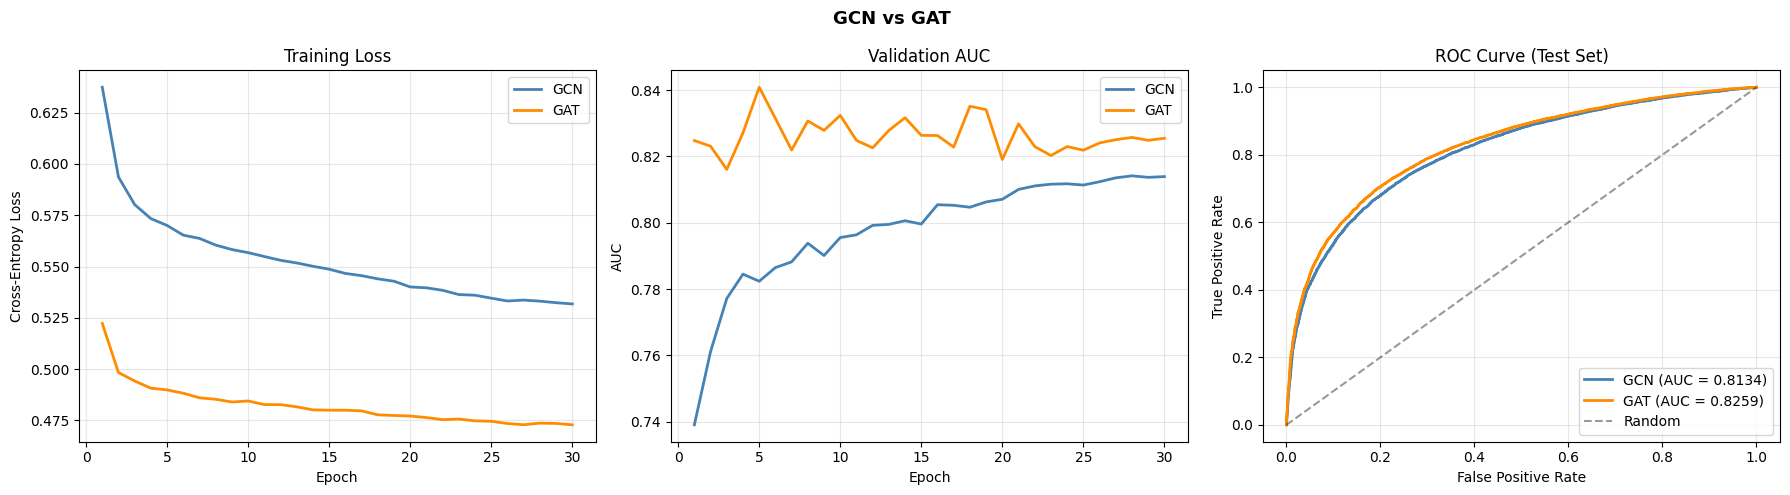

Saved to /kaggle/working/gcn_vs_gat_results.png


In [ ]:
ep_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GCN vs GAT ',
             fontsize=13, fontweight='bold')

# Training Loss
axes[0].plot(ep_range, gcn_hist['loss'], label='GCN', color='steelblue',  lw=2)
axes[0].plot(ep_range, gat_hist['loss'], label='GAT', color='darkorange', lw=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation AUC
axes[1].plot(ep_range, gcn_hist['val_auc'], label='GCN', color='steelblue',  lw=2)
axes[1].plot(ep_range, gat_hist['val_auc'], label='GAT', color='darkorange', lw=2)
axes[1].set_title('Validation AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ROC Curve
gcn_fpr, gcn_tpr, _ = roc_curve(gcn_labels, gcn_probs)
gat_fpr, gat_tpr, _ = roc_curve(gat_labels, gat_probs)
axes[2].plot(gcn_fpr, gcn_tpr, label=f'GCN (AUC = {gcn_auc:.4f})', color='steelblue',  lw=2)
axes[2].plot(gat_fpr, gat_tpr, label=f'GAT (AUC = {gat_auc:.4f})', color='darkorange', lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[2].set_title('ROC Curve (Test Set)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Data Visualization Plot 

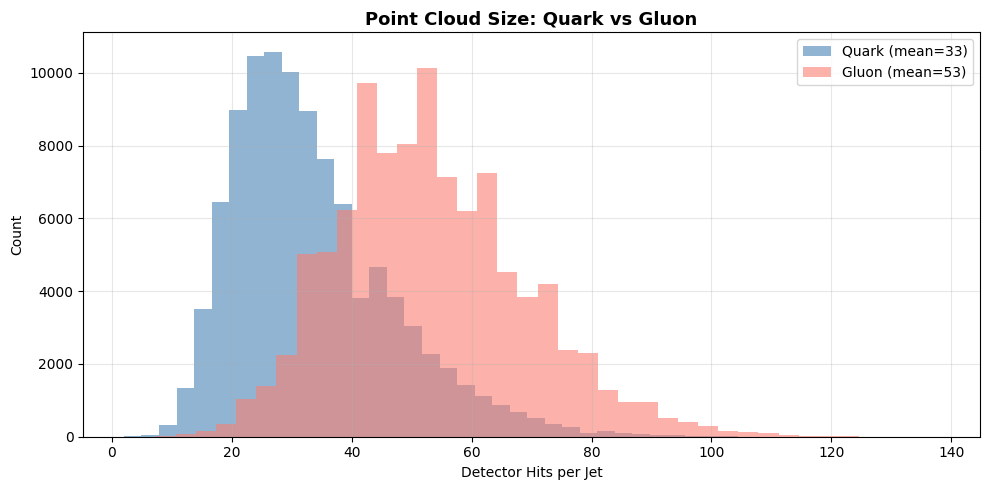

In [ ]:
quark_sizes = [(X[i, :, 0] > 0).sum() for i in np.where(y == 1)[0]]
gluon_sizes = [(X[i, :, 0] > 0).sum() for i in np.where(y == 0)[0]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(quark_sizes, bins=40, alpha=0.6, color='steelblue', label=f'Quark (mean={int(np.mean(quark_sizes))})')
ax.hist(gluon_sizes, bins=40, alpha=0.6, color='salmon',    label=f'Gluon (mean={int(np.mean(gluon_sizes))})')
ax.set_title('Point Cloud Size: Quark vs Gluon', fontsize=13, fontweight='bold')
ax.set_xlabel('Detector Hits per Jet')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/pointcloud_size.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Performance Summary

Based on the test evaluation results:
- GCN  achieved better overall accuracy (**0.7400**) compared to GAT (**0.6771**).
- GAT  achieved a slightly better ROC-AUC score (**0.8259**) compared to GCN (**0.8134**).

This suggests that while GCN classifies the test samples more accurately at the default threshold, GAT has a marginally better capability in ranking the probabilities (distinguishing between the positive and negative classes ie quarks and gluons ).